In [23]:
import h5py 
import numpy as np
import matplotlib.pyplot as plt

old_file = '/mnt/home/gverza/ceph/test_main.h5'
new_file = '/mnt/home/gverza/ceph/test_box.h5'

In [10]:
Ncells_in_void = dict()
Vol_interp = dict()
Xcm = dict()
void_selected = dict()
for ii in range(2):
    with h5py.File([old_file,new_file][ii]) as ff:
        Ncells_in_void[ii] = ff['Ncells_in_void'][()]
        Vol_interp[ii] = ff['Vol_interp'][()]
        Xcm[ii] = ff['Xcm'][()]
        void_selected[ii] = ff['void_selected'][()]
        print(ff.keys())

<KeysViewHDF5 ['ID_voro_dict', 'Ncells_in_void', 'Vol_interp', 'Xcm', 'ell_eigenvalues', 'ell_eigenvectors', 'void_selected']>
<KeysViewHDF5 ['ID_voro_dict', 'Ncells_in_void', 'Vol_interp', 'Xcm', 'ell_eigenvalues', 'ell_eigenvectors', 'void_selected']>


In [16]:
for ii in range(2):
    print(Ncells_in_void[ii].shape)
    print(Vol_interp[ii].shape)
    print(Xcm[ii].shape)
print(np.min(Ncells_in_void[0]))
print(np.max(np.abs(Ncells_in_void[0]-Ncells_in_void[1])))
print(np.max(np.abs(Vol_interp[0]-Vol_interp[1])))
print(np.max(np.abs(Xcm[0]-Xcm[1])))

(214, 2)
(214, 2)
(214, 2, 3)
(214, 2)
(214, 2)
(214, 2, 3)
0.0
0.0
0.001953125
2.8421709430404007e-13


In [12]:
print(Xcm[0][:10,1,:])
#print(Ncells_in_void[0][:10,:])
print(Xcm[1][:10,1,:])

[[-261.66993502 -204.47121437  103.57896041]
 [ 230.91752986 -260.07774139   39.71131513]
 [-140.51738628 -308.17081802   13.56799668]
 [ 209.30304268 -232.26847182   36.38021577]
 [ 179.39876622 -133.32863515  195.53312108]
 [-106.86895052 -362.74812393    3.13512088]
 [ -25.49432426 -167.52337477  373.31164106]
 [ 217.18015428 -253.1074055   111.08565515]
 [-248.42301035 -161.48404271  183.52805748]
 [ 108.86489411 -148.98354486  274.3071993 ]]
[[-261.66993502 -204.47121437  103.57896041]
 [ 230.91752986 -260.07774139   39.71131513]
 [-140.51738628 -308.17081802   13.56799668]
 [ 209.30304268 -232.26847182   36.38021577]
 [ 179.39876622 -133.32863515  195.53312108]
 [-106.86895052 -362.74812393    3.13512088]
 [ -25.49432426 -167.52337477  373.31164106]
 [ 217.18015428 -253.1074055   111.08565515]
 [-248.42301035 -161.48404271  183.52805748]
 [ 108.86489411 -148.98354486  274.3071993 ]]


In [15]:

print(np.max(np.abs(Xcm[0][Ncells_in_void[0][:,0]>0,0,:]-Xcm[1][Ncells_in_void[1][:,0]>0,0,:])))

1.1368683772161603e-13


In [21]:
print(np.max(np.abs(Vol_interp[0][Ncells_in_void[0][:,0]>2,0]-Vol_interp[1][Ncells_in_void[1][:,0]>2,0])))

0.001953125


/tmp/ipykernel_77143/1111756602.py:1: RuntimeWarning: invalid value encountered in divide
  plt.scatter(Ncells_in_void[0][:,0],Vol_interp[0][:,0]/Vol_interp[1][:,0]-1)


[]

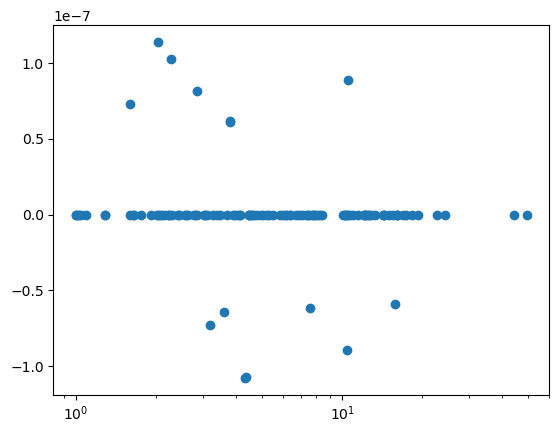

In [27]:
plt.scatter(Ncells_in_void[0][:,0],Vol_interp[0][:,0]/Vol_interp[1][:,0]-1)
plt.semilogx()